# EDA: Outlier Percentile 範圍比較

## 目標
比較 1%-99%、2.5%-97.5% 和 5%-95% 三種 outlier 處理方式，
協助決定後續實驗要固定使用哪一種 percentile 範圍。

## 比較範圍
1. **1%-99% percentile** - 較寬鬆的範圍，保留更多樣本
2. **2.5%-97.5% percentile** - 中等嚴格範圍，兼顧穩健與樣本保留
3. **5%-95% percentile** - 較嚴格的範圍，裁剪更多極端值

## 分析重點
- 各範圍裁剪掉多少樣本？
- 被裁剪樣本的分布特徵
- 三種範圍的統計差異
- 建議使用哪種範圍進行實驗

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 設定繁體中文字體
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 設定顯示風格
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

# 設定 pandas 顯示選項
pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 2)

## 1. 載入數據

In [20]:
# 讀取訓練數據
df = pd.read_csv('../dataset/train.csv')

# 建立 gender mapping: 1=男, 2=女
GENDER_MAPPING = {1: '男', 2: '女'}
df['gender_label'] = df['gender'].map(GENDER_MAPPING)

print(f"總樣本數: {len(df)}")
print(f"\nGender 分布:")
print(df['gender_label'].value_counts())
print(f"\n前 5 筆數據:")
df.head()

總樣本數: 423

Gender 分布:
gender_label
男    316
女    107
Name: count, dtype: int64

前 5 筆數據:


,id,gender,star_sign,phone_os,height,weight,sleepiness,iq,fb_friends,yt,self_intro,gender_label
0,1,2,處女座,Apple,154.0,43.0,NaN,NaN,583.0,0,Beautiful,女
1,2,2,處女座,Apple,156.0,47.0,NaN,130.0,NaN,3.5,Enjoying being who I'm notsss,女
2,3,1,射手座,NaN,170.0,61.0,NaN,90.0,540.0,NaN,Practice Makes perfect,男
3,4,1,射手座,Apple,170.0,62.0,4.0,100.0,NaN,5,Straightforward,男
4,5,2,射手座,Android,158.0,67.0,NaN,128.0,320.0,1.2,Humorous,女


## 2. 定義 Percentile 範圍

In [21]:
# 定義三種 percentile 範圍
PERCENTILE_RANGES = {
    '1%-99%': {'lower': 0.01, 'upper': 0.99},
    '2.5%-97.5%': {'lower': 0.025, 'upper': 0.975},
    '5%-95%': {'lower': 0.05, 'upper': 0.95}
}

# 需要分析的特徵
FEATURES = ['weight', 'height']
GENDERS = ['男', '女']

print("定義的 Percentile 範圍:")
for range_name, bounds in PERCENTILE_RANGES.items():
    print(f"  {range_name}: {bounds['lower']*100:.0f}% - {bounds['upper']*100:.0f}%")

定義的 Percentile 範圍:
  1%-99%: 1% - 99%
  2.5%-97.5%: 2% - 98%
  5%-95%: 5% - 95%


## 3. 計算各範圍的統計資訊

In [22]:
def calculate_percentile_bounds(df, gender, feature, lower_pct, upper_pct):
    """
    計算指定性別和特徵的 percentile 範圍
    """
    subset = df[df['gender_label'] == gender][feature].dropna()
    lower_bound = subset.quantile(lower_pct)
    upper_bound = subset.quantile(upper_pct)
    return lower_bound, upper_bound

# 建立統計表格
stats_results = []

print("=" * 100)
print("各 Percentile 範圍的統計資訊")
print("=" * 100)

for range_name, bounds in PERCENTILE_RANGES.items():
    print(f"\n{'='*50}")
    print(f"{range_name}")
    print(f"{'='*50}")
    
    for gender in GENDERS:
        for feature in FEATURES:
            subset = df[df['gender_label'] == gender][feature]
            
            # 計算 percentile 範圍
            lower_bound, upper_bound = calculate_percentile_bounds(
                df, gender, feature, bounds['lower'], bounds['upper']
            )
            
            # 統計資訊
            total_valid = subset.notna().sum()
            below_lower = (subset < lower_bound).sum()
            above_upper = (subset > upper_bound).sum()
            total_clipped = below_lower + above_upper
            clipped_pct = (total_clipped / total_valid * 100) if total_valid > 0 else 0
            
            # 保存結果
            stats_results.append({
                'Percentile範圍': range_name,
                '性別': gender,
                '特徵': feature,
                '下限': f"{lower_bound:.2f}",
                '上限': f"{upper_bound:.2f}",
                '有效樣本數': total_valid,
                '低於下限': below_lower,
                '高於上限': above_upper,
                '總裁剪數': total_clipped,
                '裁剪比例(%)': f"{clipped_pct:.2f}"
            })
            
            print(f"\n{gender} - {feature}:")
            print(f"  範圍: [{lower_bound:.2f}, {upper_bound:.2f}]")
            print(f"  有效樣本: {total_valid}")
            print(f"  低於下限: {below_lower} 筆")
            print(f"  高於上限: {above_upper} 筆")
            print(f"  總裁剪: {total_clipped} 筆 ({clipped_pct:.2f}%)")

# 轉換為 DataFrame
stats_df = pd.DataFrame(stats_results)
print("\n" + "=" * 100)
print("統計總表")
print("=" * 100)
stats_df

各 Percentile 範圍的統計資訊

1%-99%

男 - weight:
  範圍: [11.14, 183.01]
  有效樣本: 258
  低於下限: 3 筆
  高於上限: 3 筆
  總裁剪: 6 筆 (2.33%)

男 - height:
  範圍: [65.91, 203.70]
  有效樣本: 264
  低於下限: 3 筆
  高於上限: 3 筆
  總裁剪: 6 筆 (2.27%)

女 - weight:
  範圍: [36.07, 168.20]
  有效樣本: 80
  低於下限: 1 筆
  高於上限: 1 筆
  總裁剪: 2 筆 (2.50%)

女 - height:
  範圍: [149.52, 295.20]
  有效樣本: 85
  低於下限: 1 筆
  高於上限: 1 筆
  總裁剪: 2 筆 (2.35%)

2.5%-97.5%

男 - weight:
  範圍: [44.00, 105.75]
  有效樣本: 258
  低於下限: 6 筆
  高於上限: 7 筆
  總裁剪: 13 筆 (5.04%)

男 - height:
  範圍: [155.75, 190.00]
  有效樣本: 264
  低於下限: 7 筆
  高於上限: 6 筆
  總裁剪: 13 筆 (4.92%)

女 - weight:
  範圍: [43.00, 80.00]
  有效樣本: 80
  低於下限: 1 筆
  高於上限: 1 筆
  總裁剪: 2 筆 (2.50%)

女 - height:
  範圍: [150.00, 179.90]
  有效樣本: 85
  低於下限: 1 筆
  高於上限: 3 筆
  總裁剪: 4 筆 (4.71%)

5%-95%

男 - weight:
  範圍: [49.00, 90.00]
  有效樣本: 258
  低於下限: 12 筆
  高於上限: 12 筆
  總裁剪: 24 筆 (9.30%)

男 - height:
  範圍: [163.00, 185.00]
  有效樣本: 264
  低於下限: 11 筆
  高於上限: 11 筆
  總裁剪: 22 筆 (8.33%)

女 - weight:
  範圍: [44.95, 78.10]
  有效樣本: 80


,Percentile範圍,性別,特徵,下限,上限,有效樣本數,低於下限,高於上限,總裁剪數,裁剪比例(%)
0,1%-99%,男,weight,11.14,183.01,258,3,3,6,2.33
1,1%-99%,男,height,65.91,203.70,264,3,3,6,2.27
2,1%-99%,女,weight,36.07,168.20,80,1,1,2,2.50
3,1%-99%,女,height,149.52,295.20,85,1,1,2,2.35
4,2.5%-97.5%,男,weight,44.00,105.75,258,6,7,13,5.04
5,2.5%-97.5%,男,height,155.75,190.00,264,7,6,13,4.92
6,2.5%-97.5%,女,weight,43.00,80.00,80,1,1,2,2.50
7,2.5%-97.5%,女,height,150.00,179.90,85,1,3,4,4.71
8,5%-95%,男,weight,49.00,90.00,258,12,12,24,9.30
9,5%-95%,男,height,163.00,185.00,264,11,11,22,8.33


## 4. 三種範圍的對比分析

In [23]:
# 按 Percentile 範圍分組比較
print("=" * 100)
print("三種 Percentile 範圍的整體影響比較")
print("=" * 100)

comparison_summary = []

for range_name in PERCENTILE_RANGES.keys():
    subset = stats_df[stats_df['Percentile範圍'] == range_name].copy()
    
    # 轉換字串為數值
    subset['總裁剪數_num'] = pd.to_numeric(subset['總裁剪數'])
    subset['有效樣本數_num'] = pd.to_numeric(subset['有效樣本數'])
    
    total_clipped = subset['總裁剪數_num'].sum()
    total_valid = subset['有效樣本數_num'].sum()
    overall_pct = (total_clipped / total_valid * 100) if total_valid > 0 else 0
    
    comparison_summary.append({
        'Percentile範圍': range_name,
        '總有效樣本': total_valid,
        '總裁剪樣本': total_clipped,
        '整體裁剪比例(%)': f"{overall_pct:.2f}"
    })
    
    print(f"\n{range_name}:")
    print(f"  總有效樣本: {total_valid}")
    print(f"  總裁剪樣本: {total_clipped}")
    print(f"  整體裁剪比例: {overall_pct:.2f}%")

comparison_df = pd.DataFrame(comparison_summary)
print("\n" + "=" * 100)
comparison_df

三種 Percentile 範圍的整體影響比較

1%-99%:
  總有效樣本: 687
  總裁剪樣本: 16
  整體裁剪比例: 2.33%

2.5%-97.5%:
  總有效樣本: 687
  總裁剪樣本: 32
  整體裁剪比例: 4.66%

5%-95%:
  總有效樣本: 687
  總裁剪樣本: 64
  整體裁剪比例: 9.32%



,Percentile範圍,總有效樣本,總裁剪樣本,整體裁剪比例(%)
0,1%-99%,687,16,2.33
1,2.5%-97.5%,687,32,4.66
2,5%-95%,687,64,9.32


## 5. 分性別、分特徵的詳細比較

In [24]:
# 建立比較表：每個性別+特徵組合，比較三種範圍
print("=" * 100)
print("分性別、分特徵的範圍比較")
print("=" * 100)

for gender in GENDERS:
    print(f"\n{'='*50}")
    print(f"{gender}")
    print(f"{'='*50}")
    
    for feature in FEATURES:
        print(f"\n  {feature}:")
        
        # 篩選該性別和特徵的資料
        subset = stats_df[
            (stats_df['性別'] == gender) & 
            (stats_df['特徵'] == feature)
        ][['Percentile範圍', '下限', '上限', '總裁剪數', '裁剪比例(%)']]
        
        print(subset.to_string(index=False))
        
        # 計算差異
        if len(subset) >= 2:
            clipped_values = subset['總裁剪數'].astype(int)
            diff = clipped_values.max() - clipped_values.min()
            print(f"\n    裁剪數最大差異: {diff} 筆")

分性別、分特徵的範圍比較

男

  weight:
Percentile範圍    下限     上限  總裁剪數 裁剪比例(%)
      1%-99% 11.14 183.01     6    2.33
  2.5%-97.5% 44.00 105.75    13    5.04
      5%-95% 49.00  90.00    24    9.30

    裁剪數最大差異: 18 筆

  height:
Percentile範圍     下限     上限  總裁剪數 裁剪比例(%)
      1%-99%  65.91 203.70     6    2.27
  2.5%-97.5% 155.75 190.00    13    4.92
      5%-95% 163.00 185.00    22    8.33

    裁剪數最大差異: 16 筆

女

  weight:
Percentile範圍    下限     上限  總裁剪數 裁剪比例(%)
      1%-99% 36.07 168.20     2    2.50
  2.5%-97.5% 43.00  80.00     2    2.50
      5%-95% 44.95  78.10     8   10.00

    裁剪數最大差異: 6 筆

  height:
Percentile範圍     下限     上限  總裁剪數 裁剪比例(%)
      1%-99% 149.52 295.20     2    2.35
  2.5%-97.5% 150.00 179.90     4    4.71
      5%-95% 151.34 175.60    10   11.76

    裁剪數最大差異: 8 筆


## 6. 視覺化比較

/tmp/ipykernel_29250/1822818437.py:51: UserWarning: Glyph 30007 (\N{CJK UNIFIED IDEOGRAPH-7537}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_29250/1822818437.py:51: UserWarning: Glyph 22899 (\N{CJK UNIFIED IDEOGRAPH-5973}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_29250/1822818437.py:51: UserWarning: Glyph 24615 (\N{CJK UNIFIED IDEOGRAPH-6027}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_29250/1822818437.py:51: UserWarning: Glyph 21029 (\N{CJK UNIFIED IDEOGRAPH-5225}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_29250/1822818437.py:51: UserWarning: Glyph 35009 (\N{CJK UNIFIED IDEOGRAPH-88C1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_29250/1822818437.py:51: UserWarning: Glyph 21098 (\N{CJK UNIFIED IDEOGRAPH-526A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_29250/1822818437.py:51: UserWarning: Glyph 27604 (\N{CJK UNIFIED IDEOGRAP

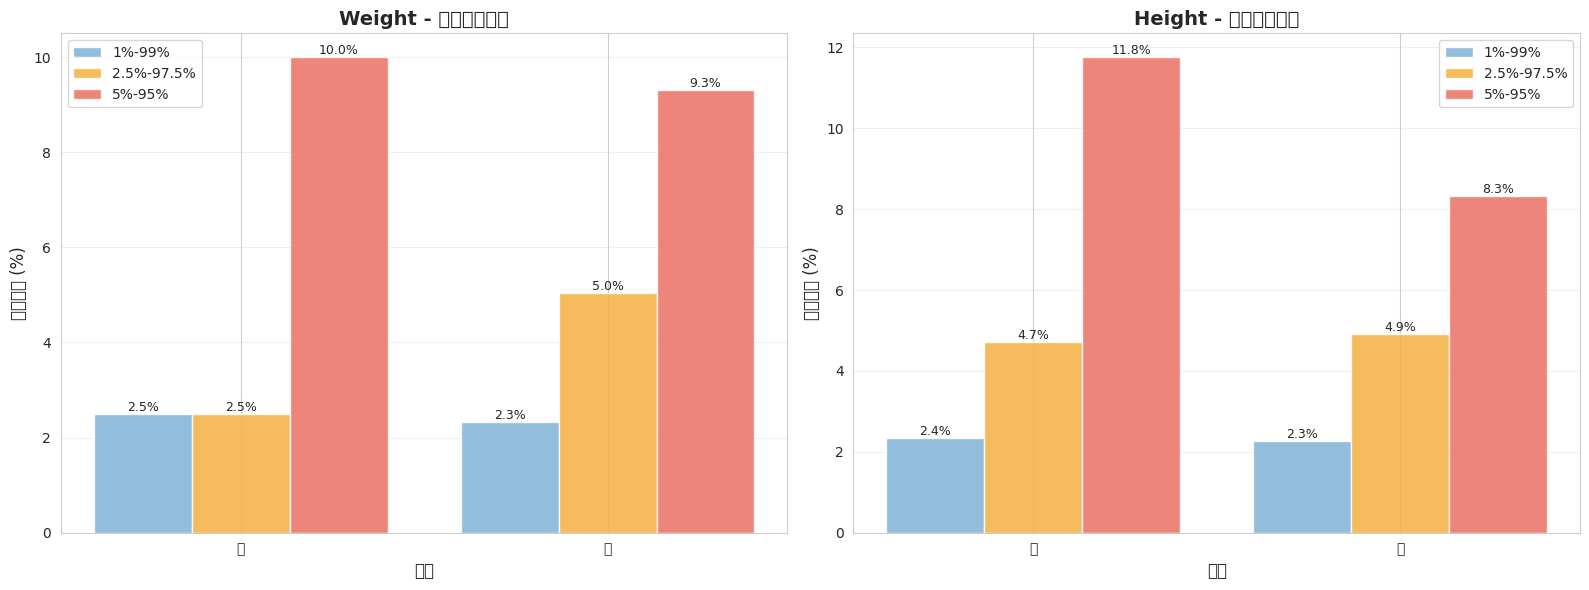

圖表已儲存至: result/percentile_clipping_comparison.png


In [25]:
# 6.1 裁剪比例長條圖
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
range_names = list(PERCENTILE_RANGES.keys())
range_colors = {'1%-99%': '#7fb3d5', '2.5%-97.5%': '#f5b041', '5%-95%': '#ec7063'}

for idx, feature in enumerate(FEATURES):
    ax = axes[idx]
    
    # 篩選該特徵的資料
    plot_data = stats_df[stats_df['特徵'] == feature].copy()
    
    # 轉換裁剪比例為數值
    plot_data['裁剪比例_num'] = plot_data['裁剪比例(%)'].str.rstrip('%').astype(float)
    
    # 繪製分組長條圖
    x = np.arange(len(GENDERS))
    bar_count = len(range_names)
    width = 0.8 / bar_count

    for ridx, range_name in enumerate(range_names):
        range_data = plot_data[plot_data['Percentile範圍'] == range_name].sort_values('性別')
        offset = (ridx - (bar_count - 1) / 2) * width
        bars = ax.bar(
            x + offset,
            range_data['裁剪比例_num'].values,
            width,
            label=range_name,
            alpha=0.85,
            color=range_colors.get(range_name, '#95a5a6')
        )

        for bar in bars:
            height = bar.get_height()
            ax.text(
                bar.get_x() + bar.get_width() / 2.,
                height,
                f'{height:.1f}%',
                ha='center',
                va='bottom',
                fontsize=9
            )
    
    ax.set_xlabel('性別', fontsize=12)
    ax.set_ylabel('裁剪比例 (%)', fontsize=12)
    ax.set_title(f'{feature.capitalize()} - 裁剪比例比較', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(GENDERS)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../result/percentile_clipping_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("圖表已儲存至: result/percentile_clipping_comparison.png")

/tmp/ipykernel_29250/1535348711.py:37: UserWarning: Glyph 30007 (\N{CJK UNIFIED IDEOGRAPH-7537}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_29250/1535348711.py:37: UserWarning: Glyph 19979 (\N{CJK UNIFIED IDEOGRAPH-4E0B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_29250/1535348711.py:37: UserWarning: Glyph 38480 (\N{CJK UNIFIED IDEOGRAPH-9650}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_29250/1535348711.py:37: UserWarning: Glyph 19978 (\N{CJK UNIFIED IDEOGRAPH-4E0A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_29250/1535348711.py:37: UserWarning: Glyph 22899 (\N{CJK UNIFIED IDEOGRAPH-5973}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_29250/1535348711.py:38: UserWarning: Glyph 30007 (\N{CJK UNIFIED IDEOGRAPH-7537}) missing from font(s) DejaVu Sans.
  plt.savefig('../result/percentile_distribution_boxplot.png', dpi=150, bbox_inches='tight')
/tmp/ipykernel_2

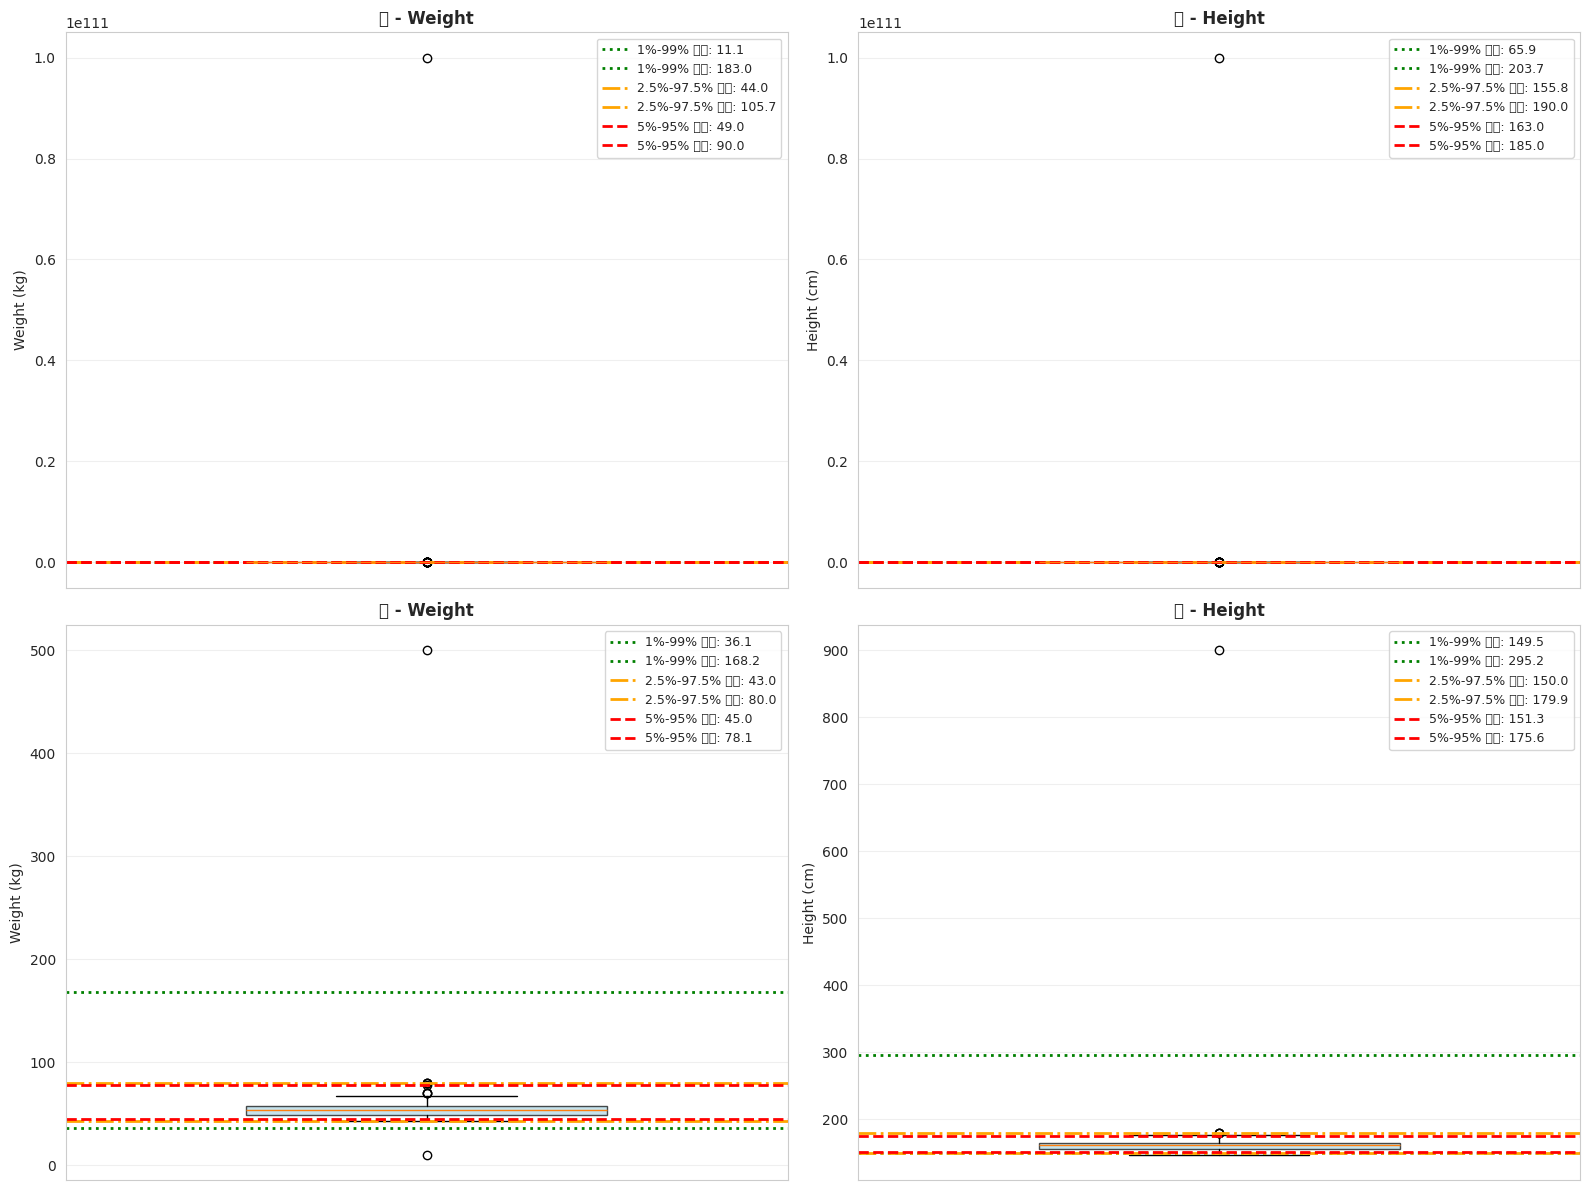

圖表已儲存至: result/percentile_distribution_boxplot.png


In [26]:
# 6.2 分布箱型圖 + Percentile 範圍標記
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for idx, gender in enumerate(GENDERS):
    subset = df[df['gender_label'] == gender]
    
    for jdx, feature in enumerate(FEATURES):
        ax = axes[idx, jdx]
        
        # 繪製箱型圖
        data = subset[feature].dropna()
        ax.boxplot([data], vert=True, widths=0.5, patch_artist=True,
                   boxprops=dict(facecolor='lightblue', alpha=0.7))
        
        # 標記三種 percentile 範圍
        colors = {'1%-99%': 'green', '2.5%-97.5%': 'orange', '5%-95%': 'red'}
        linestyles = {'1%-99%': ':', '2.5%-97.5%': '-.', '5%-95%': '--'}
        
        for range_name, bounds in PERCENTILE_RANGES.items():
            lower, upper = calculate_percentile_bounds(
                df, gender, feature, bounds['lower'], bounds['upper']
            )
            
            ax.axhline(lower, color=colors[range_name], 
                      linestyle=linestyles[range_name], linewidth=2,
                      label=f'{range_name} 下限: {lower:.1f}')
            ax.axhline(upper, color=colors[range_name], 
                      linestyle=linestyles[range_name], linewidth=2,
                      label=f'{range_name} 上限: {upper:.1f}')
        
        ax.set_title(f'{gender} - {feature.capitalize()}', fontsize=12, fontweight='bold')
        ax.set_ylabel(f'{feature.capitalize()} ({"kg" if feature == "weight" else "cm"})')
        ax.legend(loc='best', fontsize=9)
        ax.grid(alpha=0.3)
        ax.set_xticks([])

plt.tight_layout()
plt.savefig('../result/percentile_distribution_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

print("圖表已儲存至: result/percentile_distribution_boxplot.png")

/tmp/ipykernel_29250/1176083582.py:29: UserWarning: Glyph 31684 (\N{CJK UNIFIED IDEOGRAPH-7BC4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_29250/1176083582.py:29: UserWarning: Glyph 22285 (\N{CJK UNIFIED IDEOGRAPH-570D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_29250/1176083582.py:29: UserWarning: Glyph 32317 (\N{CJK UNIFIED IDEOGRAPH-7E3D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_29250/1176083582.py:29: UserWarning: Glyph 35009 (\N{CJK UNIFIED IDEOGRAPH-88C1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_29250/1176083582.py:29: UserWarning: Glyph 21098 (\N{CJK UNIFIED IDEOGRAPH-526A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_29250/1176083582.py:29: UserWarning: Glyph 27171 (\N{CJK UNIFIED IDEOGRAPH-6A23}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_29250/1176083582.py:29: UserWarning: Glyph 26412 (\N{CJK UNIFIED IDEOGRAP

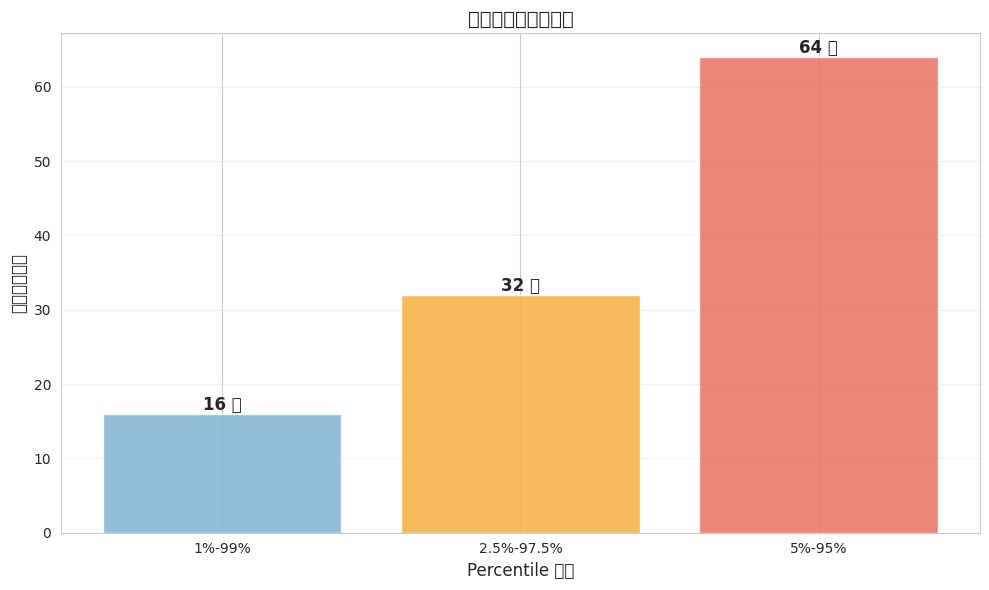

圖表已儲存至: result/percentile_total_clipped_comparison.png


In [27]:
# 6.3 裁剪樣本數比較
fig, ax = plt.subplots(figsize=(10, 6))

# 準備資料
range_names = list(PERCENTILE_RANGES.keys())
clipped_counts = []

for range_name in range_names:
    subset = stats_df[stats_df['Percentile範圍'] == range_name]
    total_clipped = pd.to_numeric(subset['總裁剪數']).sum()
    clipped_counts.append(total_clipped)

# 繪製長條圖
bar_colors = ['#7fb3d5', '#f5b041', '#ec7063'][:len(range_names)]
bars = ax.bar(range_names, clipped_counts, color=bar_colors, alpha=0.85)

# 標註數值
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
           f'{int(height)} 筆',
           ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_xlabel('Percentile 範圍', fontsize=12)
ax.set_ylabel('總裁剪樣本數', fontsize=12)
ax.set_title('整體裁剪樣本數比較', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../result/percentile_total_clipped_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("圖表已儲存至: result/percentile_total_clipped_comparison.png")

## 7. 查看被裁剪的樣本範例

In [28]:
print("=" * 100)
print("被各範圍裁剪的樣本範例")
print("=" * 100)

for range_name, bounds in PERCENTILE_RANGES.items():
    print(f"\n{'='*70}")
    print(f"{range_name}")
    print(f"{'='*70}")
    
    for gender in GENDERS:
        subset = df[df['gender_label'] == gender].copy()
        
        print(f"\n{gender}:")
        
        for feature in FEATURES:
            lower, upper = calculate_percentile_bounds(
                df, gender, feature, bounds['lower'], bounds['upper']
            )
            
            # 找出超出範圍的樣本
            outliers = subset[
                (subset[feature] < lower) | (subset[feature] > upper)
            ][['id', 'gender', 'gender_label', 'weight', 'height']].copy()
            
            if len(outliers) > 0:
                print(f"\n  {feature} 超出範圍 [{lower:.2f}, {upper:.2f}] 的樣本 (前10筆):")
                print(outliers.head(10).to_string(index=False))
            else:
                print(f"\n  {feature}: 無超出範圍的樣本")

被各範圍裁剪的樣本範例

1%-99%

男:

  weight 超出範圍 [11.14, 183.01] 的樣本 (前10筆):
 id  gender gender_label    weight    height
 62       1            男  2.00e+02  1.85e+02
127       1            男  7.00e+00  1.75e+02
134       1            男 1.00e+111 1.00e+111
292       1            男 -1.00e+03       NaN
307       1            男  1.87e+02  1.87e+02
381       1            男  1.00e+01  2.00e+02

  height 超出範圍 [65.91, 203.70] 的樣本 (前10筆):
 id  gender gender_label    weight    height
134       1            男 1.00e+111 1.00e+111
253       1            男  8.70e+01  3.00e+01
257       1            男  6.60e+01  6.66e+02
260       1            男  7.80e+01  2.10e+02
266       1            男  1.20e+01  1.20e+01
271       1            男  1.00e+02 -1.87e+02

女:

  weight 超出範圍 [36.07, 168.20] 的樣本 (前10筆):
 id  gender gender_label  weight  height
254       2            女   500.0     NaN
308       2            女    10.0   900.0

  height 超出範圍 [149.52, 295.20] 的樣本 (前10筆):
 id  gender gender_label  weight  height
263  

## 8. 三範圍重疊分析

In [30]:
print("=" * 100)
print("範圍重疊分析：比較較嚴格範圍是否包含在較寬鬆範圍內")
print("=" * 100)

overlap_results = []

for gender in GENDERS:
    subset = df[df['gender_label'] == gender].copy()
    
    print(f"\n{gender}:")
    
    for feature in FEATURES:
        # 計算三種範圍
        lower_1_99, upper_1_99 = calculate_percentile_bounds(
            df, gender, feature, 0.01, 0.99
        )
        lower_2_5_97_5, upper_2_5_97_5 = calculate_percentile_bounds(
            df, gender, feature, 0.025, 0.975
        )
        lower_5_95, upper_5_95 = calculate_percentile_bounds(
            df, gender, feature, 0.05, 0.95
        )
        
        # 找出各範圍裁剪樣本
        clipped_1_99 = subset[
            (subset[feature] < lower_1_99) | (subset[feature] > upper_1_99)
        ].index
        clipped_2_5_97_5 = subset[
            (subset[feature] < lower_2_5_97_5) | (subset[feature] > upper_2_5_97_5)
        ].index
        clipped_5_95 = subset[
            (subset[feature] < lower_5_95) | (subset[feature] > upper_5_95)
        ].index
        
        # 計算重疊
        overlap_2_5_in_1_99 = len(set(clipped_2_5_97_5) & set(clipped_1_99))
        overlap_5_in_2_5 = len(set(clipped_5_95) & set(clipped_2_5_97_5))
        overlap_5_in_1_99 = len(set(clipped_5_95) & set(clipped_1_99))

        overlap_2_5_pct = (overlap_2_5_in_1_99 / len(clipped_2_5_97_5) * 100) if len(clipped_2_5_97_5) > 0 else 0
        overlap_5_in_2_5_pct = (overlap_5_in_2_5 / len(clipped_5_95) * 100) if len(clipped_5_95) > 0 else 0
        overlap_5_in_1_99_pct = (overlap_5_in_1_99 / len(clipped_5_95) * 100) if len(clipped_5_95) > 0 else 0
        
        overlap_results.append({
            '性別': gender,
            '特徵': feature,
            '1%-99%裁剪數': len(clipped_1_99),
            '2.5%-97.5%裁剪數': len(clipped_2_5_97_5),
            '5%-95%裁剪數': len(clipped_5_95),
            '2.5%與1%重疊數': overlap_2_5_in_1_99,
            '2.5%與1%重疊比例(%)': f"{overlap_2_5_pct:.2f}",
            '5%與2.5%重疊數': overlap_5_in_2_5,
            '5%與2.5%重疊比例(%)': f"{overlap_5_in_2_5_pct:.2f}",
            '5%與1%重疊數': overlap_5_in_1_99,
            '5%與1%重疊比例(%)': f"{overlap_5_in_1_99_pct:.2f}"
        })
        
        print(f"\n  {feature}:")
        print(f"    1%-99% 裁剪: {len(clipped_1_99)} 筆")
        print(f"    2.5%-97.5% 裁剪: {len(clipped_2_5_97_5)} 筆")
        print(f"    5%-95% 裁剪: {len(clipped_5_95)} 筆")
        print(f"    2.5%-97.5% 與 1%-99% 重疊: {overlap_2_5_in_1_99} 筆 ({overlap_2_5_pct:.2f}%)")
        print(f"    5%-95% 與 2.5%-97.5% 重疊: {overlap_5_in_2_5} 筆 ({overlap_5_in_2_5_pct:.2f}%)")
        print(f"    5%-95% 與 1%-99% 重疊: {overlap_5_in_1_99} 筆 ({overlap_5_in_1_99_pct:.2f}%)")

overlap_df = pd.DataFrame(overlap_results)
print("\n" + "=" * 100)
overlap_df

範圍重疊分析：比較較嚴格範圍是否包含在較寬鬆範圍內

男:

  weight:
    1%-99% 裁剪: 6 筆
    2.5%-97.5% 裁剪: 13 筆
    5%-95% 裁剪: 24 筆
    2.5%-97.5% 與 1%-99% 重疊: 6 筆 (46.15%)
    5%-95% 與 2.5%-97.5% 重疊: 13 筆 (54.17%)
    5%-95% 與 1%-99% 重疊: 6 筆 (25.00%)

  height:
    1%-99% 裁剪: 6 筆
    2.5%-97.5% 裁剪: 13 筆
    5%-95% 裁剪: 22 筆
    2.5%-97.5% 與 1%-99% 重疊: 6 筆 (46.15%)
    5%-95% 與 2.5%-97.5% 重疊: 13 筆 (59.09%)
    5%-95% 與 1%-99% 重疊: 6 筆 (27.27%)

女:

  weight:
    1%-99% 裁剪: 2 筆
    2.5%-97.5% 裁剪: 2 筆
    5%-95% 裁剪: 8 筆
    2.5%-97.5% 與 1%-99% 重疊: 2 筆 (100.00%)
    5%-95% 與 2.5%-97.5% 重疊: 2 筆 (25.00%)
    5%-95% 與 1%-99% 重疊: 2 筆 (25.00%)

  height:
    1%-99% 裁剪: 2 筆
    2.5%-97.5% 裁剪: 4 筆
    5%-95% 裁剪: 10 筆
    2.5%-97.5% 與 1%-99% 重疊: 2 筆 (50.00%)
    5%-95% 與 2.5%-97.5% 重疊: 4 筆 (40.00%)
    5%-95% 與 1%-99% 重疊: 2 筆 (20.00%)



,性別,特徵,1%-99%裁剪數,2.5%-97.5%裁剪數,5%-95%裁剪數,2.5%與1%重疊數,2.5%與1%重疊比例(%),5%與2.5%重疊數,5%與2.5%重疊比例(%),5%與1%重疊數,5%與1%重疊比例(%)
0,男,weight,6,13,24,6,46.15,13,54.17,6,25.00
1,男,height,6,13,22,6,46.15,13,59.09,6,27.27
2,女,weight,2,2,8,2,100.00,2,25.00,2,25.00
3,女,height,2,4,10,2,50.00,4,40.00,2,20.00


## 9. 結論與建議

In [ ]:
print("\n" + "=" * 100)
print("分析結論與實驗建議")
print("=" * 100)

# 計算各範圍整體裁剪比例
range_pct_map = {
    row['Percentile範圍']: float(str(row['整體裁剪比例(%)']).rstrip('%'))
    for _, row in comparison_df.iterrows()
}
sorted_ranges = sorted(range_pct_map.items(), key=lambda x: x[1])
best_range, best_pct = sorted_ranges[0]
second_range, second_pct = sorted_ranges[1]
strictest_range, strictest_pct = sorted_ranges[-1]

print(f"\n1. 整體裁剪比例對比:")
for range_name, pct in sorted_ranges:
    print(f"   - {range_name} percentile: {pct:.2f}%")
print(f"   - 最低與最高差異: {strictest_pct - best_pct:.2f} 百分點")

print(f"\n2. 範圍選擇建議:")
if best_pct < 5:
    print(f"   建議優先使用 {best_range} percentile")
    print("   理由：裁剪比例低 (< 5%)，可以保留更多有效樣本進行訓練")
elif best_pct < 10:
    print(f"   建議先測試 {best_range} percentile")
    print(f"   理由：裁剪比例適中 (5-10%)，可再用 {second_range} 作為對照")
else:
    print("   建議三種範圍都先做基準測試")
    print("   理由：整體裁剪比例偏高，需要實驗驗證最佳配置")

print(f"\n3. 實驗矩陣簡化建議:")
imputation_strategies = ['median', 'mean', 'mode', 'knn']
original_experiments = len(PERCENTILE_RANGES) * len(imputation_strategies)
simplified_experiments = len(imputation_strategies)
saved_pct = (1 - simplified_experiments / original_experiments) * 100
print(f"   原本實驗數: {original_experiments} 個 ({len(PERCENTILE_RANGES)}種percentile × {len(imputation_strategies)}種補值策略)")
print(f"   簡化後: {simplified_experiments} 個 (選擇1種percentile × {len(imputation_strategies)}種補值策略)")
print(f"   節省實驗數: {saved_pct:.0f}%")

if strictest_pct - best_pct > 5:
    print(f"\n   注意: 三種範圍中最高與最低裁剪比例差異超過 5 百分點")
    print("   建議: 如果資源允許，建議先做多範圍基準驗證再收斂")

print(f"\n4. 各性別、特徵的詳細建議:")
for _, row in stats_df.iterrows():
    pct = float(row['裁剪比例(%)'].rstrip('%'))
    if pct > 15:
        print(f"   ⚠️  {row['Percentile範圍']} - {row['性別']} - {row['特徵']}: 裁剪比例高達 {pct:.2f}%")

print(f"\n5. 下一步行動:")
if abs(second_pct - best_pct) < 1.0:
    print(f"   1) 先進行 2 個基準實驗: {best_range} 與 {second_range} (使用相同補值策略)")
    print("   2) 選擇較佳 percentile 範圍")
    print("   3) 用選定範圍測試其餘 3 種補值策略")
else:
    print(f"   1) 使用 {best_range} percentile 作為 outlier 處理範圍")
    print("   2) 進行 4 個實驗: 測試 4 種補值策略 (median, mean, mode, knn)")
    print("   3) 記錄最佳補值策略")

print("\n" + "=" * 100)


分析結論與實驗建議

1. 整體裁剪比例對比:
   - 1%-99% percentile: 2.33%
   - 5%-95% percentile: 9.32%
   - 差異: 6.99 百分點

2. 範圍選擇建議:
   ✅ 建議使用 1%-99% percentile
   理由：裁剪比例低 (< 5%)，可以保留更多有效樣本進行訓練

3. 實驗矩陣簡化建議:
   原本實驗數: 8 個 (2種percentile × 4種補值策略)
   簡化後: 4 個 (選擇1種percentile × 4種補值策略)
   節省實驗數: 50%

   ⚠️  注意: 兩種範圍的裁剪比例差異超過 5 百分點
   建議: 如果資源允許，還是建議兩種都測試，以找到最佳配置

4. 各性別、特徵的詳細建議:

5. 下一步行動:
   1️⃣  使用 1%-99% percentile 作為 outlier 處理範圍
   2️⃣  進行 4 個實驗: 測試 4 種補值策略 (median, mean, mode, knn)
   3️⃣  記錄最佳補值策略



## 10. 匯出結果

In [ ]:
# 匯出統計結果到 CSV
stats_df.to_csv('../result/percentile_comparison_stats.csv', index=False, encoding='utf-8-sig')
comparison_df.to_csv('../result/percentile_comparison_summary.csv', index=False, encoding='utf-8-sig')
overlap_df.to_csv('../result/percentile_overlap_analysis.csv', index=False, encoding='utf-8-sig')

print("結果已匯出:")
print("  - result/percentile_comparison_stats.csv (詳細統計)")
print("  - result/percentile_comparison_summary.csv (整體摘要)")
print("  - result/percentile_overlap_analysis.csv (重疊分析)")
print("\n視覺化圖表已儲存:")
print("  - result/percentile_clipping_comparison.png")
print("  - result/percentile_distribution_boxplot.png")
print("  - result/percentile_total_clipped_comparison.png")